# VisXAI: Sequence Path Demo

This notebook walks through VisXAI's fully-working **sequence** pipeline:
tokenize a SMILES string &rarr; train a tiny attention model on a
synthetic task &rarr; explain a prediction with `AttentionExplainer` &rarr;
see **both atom-level and (partial) bond-level** attribution on a colored
2D structure. See the README for an overview of the pipeline.

Unlike the tree-path demo's classifier, the tiny model here is **actually
trained** (a real gradient-descent loop, not just randomly initialized
weights) on a small synthetic label, so the attention pattern shown later
is at least honestly earned.

In [1]:
from types import SimpleNamespace

import torch
from IPython.display import SVG, display
from rdkit import Chem

from visxai.explainers.attention import AttentionExplainer
from visxai.explainers.gradient_based_sequence import GradCAMExplainer, IntegratedGradientsExplainer
from visxai.features.sequences import generate_sequence_representation
from visxai.models.pytorch_wrapper import PyTorchSequenceWrapper
from visxai.visualizers.rdkit_2d import RDKitSVGVisualizer

## The synthetic task: "does this molecule contain an aromatic ring?"

A chemically well-defined, RDKit-computable label:
`any(atom.GetIsAromatic() for atom in mol.GetAtoms())`.

The tree-path demo's 5-molecule set only gives a thin 2-positive/
3-negative split &mdash; not enough signal for a gradient-descent loop to
show honest convergence. This demo expands to 12 molecules (still tiny,
still fully hardcoded, no external data), keeping the original 5 and
adding 7 more chosen for balance and to sharpen what the model actually
has to learn:

- **pyridine** (`c1ccncc1`) &mdash; aromatic, an aromatic N-containing ring
- **ibuprofen** (`CC(C)Cc1ccc(cc1)C(C)C(=O)O`) &mdash; aromatic (a molecule with sparse explicit-bond coverage)
- **hexane** (`CCCCCC`) &mdash; non-aromatic, no ring at all
- **cyclohexane** (`C1CCCCC1`) &mdash; non-aromatic *but has a ring* &mdash;
  this is the key contrast case, so the model can't just learn "contains
  any ring token" as a shortcut
- **toluene** (`Cc1ccccc1`) &mdash; aromatic
- **acetamide** (`CC(=O)N`) &mdash; non-aromatic
- **naphthalene** (`c1ccc2ccccc2c1`) &mdash; aromatic (fused rings)

This gives a balanced 6 aromatic / 6 non-aromatic split. Aspirin stays in
the training set (not held out) but is used for the explanation
walkthrough afterward.

In [2]:
_TRAIN_SMILES = {
    "ethanol": "CCO",
    "benzene": "c1ccccc1",
    "acetic_acid": "CC(=O)O",
    "pyrrolidine": "CN1CCCC1",
    "aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "pyridine": "c1ccncc1",
    "ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "hexane": "CCCCCC",
    "cyclohexane": "C1CCCCC1",
    "toluene": "Cc1ccccc1",
    "acetamide": "CC(=O)N",
    "naphthalene": "c1ccc2ccccc2c1",
}

mol_reps = {name: generate_sequence_representation(smi) for name, smi in _TRAIN_SMILES.items()}
labels = {
    name: float(any(atom.GetIsAromatic() for atom in rep.mol.GetAtoms()))
    for name, rep in mol_reps.items()
}
print(f"{sum(labels.values()):.0f} aromatic / {len(labels)} total")
for name, label in labels.items():
    print(f"  {name:15s} aromatic={bool(label)}")

6 aromatic / 12 total
  ethanol         aromatic=False
  benzene         aromatic=True
  acetic_acid     aromatic=False
  pyrrolidine     aromatic=False
  aspirin         aromatic=True
  pyridine        aromatic=True
  ibuprofen       aromatic=True
  hexane          aromatic=False
  cyclohexane     aromatic=False
  toluene         aromatic=True
  acetamide       aromatic=False
  naphthalene     aromatic=True


## Model + training loop

A small multi-layer, multi-head self-attention classifier over token ids
&mdash; defined here and, critically, **actually
trained** below rather than left at random initialization.

In [3]:
class TinyAttentionClassifier(torch.nn.Module):
    """A minimal multi-layer, multi-head self-attention model over token ids."""

    def __init__(self, vocab_size=64, embed_dim=8, num_heads=2, num_layers=2):
        super().__init__()
        self.embedding = torch.nn.Embedding(vocab_size, embed_dim)
        self.attn_layers = torch.nn.ModuleList(
            [
                torch.nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
                for _ in range(num_layers)
            ]
        )
        self.linear = torch.nn.Linear(embed_dim, 1)

    def forward(self, input_ids, attention_mask, output_attentions=False):
        x = self.embedding(input_ids)
        key_padding_mask = attention_mask == 0
        attentions = []
        for layer in self.attn_layers:
            x, attn_weights = layer(
                x, x, x,
                key_padding_mask=key_padding_mask,
                need_weights=True,
                average_attn_weights=False,
            )
            attentions.append(attn_weights)
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        logits = self.linear(pooled)
        if output_attentions:
            return SimpleNamespace(logits=logits, attentions=tuple(attentions))
        return SimpleNamespace(logits=logits)


torch.manual_seed(0)
model = TinyAttentionClassifier()

In [4]:
# Pad token_ids/attention_mask to a common length across the training batch.
names = list(_TRAIN_SMILES.keys())
max_len = max(len(mol_reps[n].token_ids) for n in names)
PAD_ID = 0  # _VOCAB["[PAD]"] == 0

input_ids = torch.zeros((len(names), max_len), dtype=torch.long)
attention_mask = torch.zeros((len(names), max_len), dtype=torch.long)
for i, name in enumerate(names):
    ids = mol_reps[name].token_ids
    mask = mol_reps[name].attention_mask
    input_ids[i, : len(ids)] = torch.tensor(ids, dtype=torch.long)
    attention_mask[i, : len(mask)] = torch.tensor(mask, dtype=torch.long)

label_tensor = torch.tensor([[labels[n]] for n in names], dtype=torch.float)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = torch.nn.BCEWithLogitsLoss()

model.train()
for epoch in range(100):
    optimizer.zero_grad()
    out = model(input_ids=input_ids, attention_mask=attention_mask)
    loss = loss_fn(out.logits, label_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"epoch {epoch:3d}  loss={loss.item():.4f}")
print(f"epoch {epoch:3d}  loss={loss.item():.4f}  (final)")

epoch   0  loss=0.6664
epoch  10  loss=0.1564
epoch  20  loss=0.0005
epoch  30  loss=0.0000
epoch  40  loss=0.0000
epoch  50  loss=0.0000
epoch  60  loss=0.0000
epoch  70  loss=0.0000


epoch  80  loss=0.0000
epoch  90  loss=0.0000
epoch  99  loss=0.0000  (final)


### Sanity check: did the model actually learn anything?

Predictions across the 12 training molecules should spread out (not sit
at a constant ~0.5) and roughly track the true aromatic/non-aromatic
split &mdash; confirming the training loop is genuinely learning, not just
running.

In [5]:
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(input_ids=input_ids, attention_mask=attention_mask).logits)

for name, prob in zip(names, probs.squeeze(-1).tolist()):
    print(f"  {name:15s} P(aromatic)={prob:.3f}  true={bool(labels[name])}")

  ethanol         P(aromatic)=0.000  true=False
  benzene         P(aromatic)=1.000  true=True
  acetic_acid     P(aromatic)=0.000  true=False
  pyrrolidine     P(aromatic)=0.000  true=False
  aspirin         P(aromatic)=1.000  true=True
  pyridine        P(aromatic)=1.000  true=True
  ibuprofen       P(aromatic)=1.000  true=True
  hexane          P(aromatic)=0.000  true=False
  cyclohexane     P(aromatic)=0.000  true=False
  toluene         P(aromatic)=1.000  true=True
  acetamide       P(aromatic)=0.000  true=False
  naphthalene     P(aromatic)=1.000  true=True


## Explaining aspirin

Aspirin is used here because it's already verified elsewhere in the repo
to show **partial bond-level attribution**: only 2 of its 13 bonds (the
two C=O double bonds) carry an explicit character in the SMILES string, so
only those 2 can receive a `bond_scores` entry &mdash; every other bond
(including the whole aromatic ring) is implicit and has nothing to
measure. See the README's notes on the sequence path for why bond coverage is inherently partial (~7-27% on real
drug molecules).

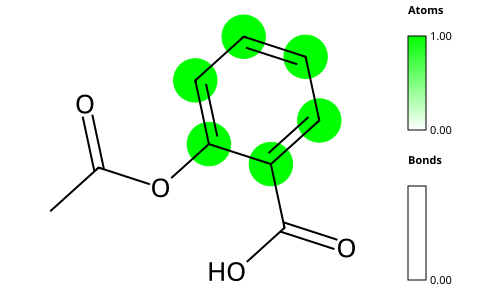

atoms scored: 13 / 13
bonds scored: 2 / 13
bond_scores: {1: 2.2649002465180423e-11, 10: 2.2649002465180423e-11}


In [6]:
wrapper = PyTorchSequenceWrapper(model)
mol_rep = mol_reps["aspirin"]

explanation = AttentionExplainer().explain(wrapper, mol_rep)
svg = RDKitSVGVisualizer().visualize(mol_rep, explanation)
display(SVG(svg))

print(f"atoms scored: {len(explanation.atom_scores)} / {mol_rep.mol.GetNumAtoms()}")
print(f"bonds scored: {len(explanation.bond_scores)} / {mol_rep.mol.GetNumBonds()}")
print("bond_scores:", explanation.bond_scores)

Every atom gets a score (dense &mdash; `atom_scores` always covers all
atoms, default `0.0`), but only the sparse subset of bonds with an
explicit SMILES character get a `bond_scores` entry at all; unattributed
bonds are **omitted entirely, not zero-filled**, so "no character to
measure" stays visually distinct from "measured, came out zero."

### Comparing aggregation strategies

`AttentionExplainer` supports two aggregation strategies. Here's the same
molecule explained with `"rollout"` (full attention-rollout across all
layers) instead of the default `"last_layer_mean_heads"`.

From here on the notebook prints each explainer's numbers rather than
re-rendering the same molecule four times; all four explanations are
loaded into the interactive dashboard at the end, where they can be
compared two at a time on a shared color scale.

In [7]:
rollout_explanation = AttentionExplainer(strategy="rollout").explain(wrapper, mol_rep)
print(f"bonds scored (rollout): {len(rollout_explanation.bond_scores)} / {mol_rep.mol.GetNumBonds()}")

bonds scored (rollout): 2 / 13


## Integrated Gradients and Grad-CAM for a CNN model

`AttentionExplainer` above only applies to models that expose attention
weights. `IntegratedGradientsExplainer`/`GradCAMExplainer` in
`visxai/explainers/gradient_based_sequence.py` work for **any** model
satisfying `PyTorchSequenceWrapper`'s `forward(input_ids,
attention_mask)` calling convention — including a plain 1-D CNN with no
attention mechanism at all. Grad-CAM specifically needs a convolutional
layer as its `target_layer`, and `TinyAttentionClassifier` above has none,
so this section trains a second, small model — a 2-layer `Conv1d`
classifier over the same token embeddings — on the exact same
aromaticity task and dataset already built above (`mol_reps`, `input_ids`,
`attention_mask`, `label_tensor`).

In [8]:
class TinyCNNClassifier(torch.nn.Module):
    """A minimal 2-layer Conv1d classifier over token embeddings.

    Padding keeps seq_len unchanged through both conv layers, so
    Grad-CAM's per-token output stays index-aligned with
    token_to_atom_map/token_to_bond_map positions.
    """

    def __init__(self, vocab_size=64, embed_dim=8, hidden_channels=8, kernel_size=3):
        super().__init__()
        self.embedding = torch.nn.Embedding(vocab_size, embed_dim)
        self.conv1 = torch.nn.Conv1d(embed_dim, hidden_channels, kernel_size, padding=kernel_size // 2)
        self.conv2 = torch.nn.Conv1d(hidden_channels, hidden_channels, kernel_size, padding=kernel_size // 2)
        self.linear = torch.nn.Linear(hidden_channels, 1)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids).transpose(1, 2)  # (B, embed_dim, seq_len)
        mask = attention_mask.unsqueeze(1).float()
        h = torch.relu(self.conv1(x)) * mask
        h = torch.relu(self.conv2(h)) * mask  # (B, hidden_channels, seq_len)
        pooled = h.sum(dim=-1) / mask.sum(dim=-1).clamp(min=1)
        return self.linear(pooled)


torch.manual_seed(0)
cnn_model = TinyCNNClassifier()
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-2)
cnn_loss_fn = torch.nn.BCEWithLogitsLoss()

cnn_model.train()
for epoch in range(100):
    cnn_optimizer.zero_grad()
    out = cnn_model(input_ids, attention_mask)
    loss = cnn_loss_fn(out, label_tensor)
    loss.backward()
    cnn_optimizer.step()
    if epoch % 10 == 0:
        print(f"epoch {epoch:3d}  loss={loss.item():.4f}")
print(f"epoch {epoch:3d}  loss={loss.item():.4f}  (final)")

epoch   0  loss=0.6939
epoch  10  loss=0.3884
epoch  20  loss=0.0784
epoch  30  loss=0.0053
epoch  40  loss=0.0005
epoch  50  loss=0.0002
epoch  60  loss=0.0001


epoch  70  loss=0.0001
epoch  80  loss=0.0001
epoch  90  loss=0.0001
epoch  99  loss=0.0000  (final)


### Integrated Gradients

Signed scores (unlike attention's non-negative weights) — shows what
pushes the prediction down as well as up. `embedding_layer` is required
and explicit (no auto-detection), the same "don't guess a model-specific
detail" principle used everywhere else in this package.

Note: unlike the graph path, `sum(atom_scores) + sum(bond_scores)` does
**not** equal `predicted_value - baseline_prediction` here — completeness
holds at the raw per-token level, but `[CLS]`/`[SEP]` special tokens have
no atom/bond mapping at all, so whatever attribution mass falls on them
is dropped during aggregation (see the module docstring in
`gradient_based_sequence.py` for the full explanation).

In [9]:
cnn_wrapper = PyTorchSequenceWrapper(cnn_model)

ig_explainer = IntegratedGradientsExplainer(embedding_layer=cnn_model.embedding)
ig_explanation = ig_explainer.explain(cnn_wrapper, mol_rep)


print(f"atoms scored: {len(ig_explanation.atom_scores)} / {mol_rep.mol.GetNumAtoms()}")
print(f"bonds scored: {len(ig_explanation.bond_scores)} / {mol_rep.mol.GetNumBonds()}")
print(f"metadata: {ig_explanation.metadata}")

atoms scored: 13 / 13
bonds scored: 2 / 13
metadata: {'n_steps': 50, 'predicted_value': 13.911625862121582, 'attribution': 'sequence/duplicate'}


### Grad-CAM

Non-negative scores (the `ReLU` is part of the algorithm's own
definition), a single forward+backward pass instead of an interpolation
loop, and reflects `target_layer`'s (here, `cnn_model.conv2`, the last
conv layer) own learned representation directly.

In [10]:
cam_explainer = GradCAMExplainer(target_layer=cnn_model.conv2)
cam_explanation = cam_explainer.explain(cnn_wrapper, mol_rep)


n_nonzero_atoms = sum(1 for v in cam_explanation.atom_scores.values() if v > 0)
print(f"atoms scored: {len(cam_explanation.atom_scores)} / {mol_rep.mol.GetNumAtoms()}"
      f"  ({n_nonzero_atoms} nonzero)")
print(f"bonds scored: {len(cam_explanation.bond_scores)} / {mol_rep.mol.GetNumBonds()}")
print(f"metadata: {cam_explanation.metadata}")

atoms scored: 13 / 13  (7 nonzero)
bonds scored: 2 / 13
metadata: {'predicted_value': 13.911625862121582, 'attribution': 'sequence/duplicate'}


## Interactive exploration

Everything above renders a **static** SVG. The same explanations can be
explored interactively instead, with no re-computation: `ExplanationDashboard`
re-renders explanations that already exist, and never re-runs an explainer.

Each panel is a `MoleculeHoverWidget` — the structure paired with an
XSMILES-style SMILES strip, cross-highlighting as the cursor moves, with a
readout giving the raw score, the normalized value driving the color, and
**how that score was assembled**.

Two things to know before running this:

- It needs a **live kernel** and the `viz` extra (`pip install -e ".[viz]"`,
  which brings `ipywidgets>=8` and `anywidget`). A rendered copy on GitHub or
  nbviewer shows a blank area where the widget would be.
- Nothing here is paradigm-specific. The dashboard only touches
  `MoleculeRepresentation` and `Explanation`, so the code below is the same in
  all three demo notebooks.

In [11]:
from visxai.visualizers.interactive import ExplanationDashboard

# All four explanations describe the same molecule, so they share one mol_rep.
results = {
    "aspirin": (mol_rep, {
        "Attention (last layer)": explanation,
        "Attention (rollout)": rollout_explanation,
        "Integrated Gradients": ig_explanation,
        "Grad-CAM": cam_explanation,
    }),
}

dashboard = ExplanationDashboard.from_results(results, width=380, height=300)
print("molecules: ", dashboard.molecules)
print("explainers:", dashboard.explainers)

molecules:  ['aspirin']
explainers: ['Attention (last layer)', 'Attention (rollout)', 'Integrated Gradients', 'Grad-CAM']


### What the readout says on this path

Hovering here shows something the fingerprint path never does: the sequence
path **duplicates** rather than splits. A token that overlaps three atoms gives
its *whole* score to each of them, undivided, so the readout reads
`"1 token, in full"` rather than `"1 bit, split 6 ways"`.

That is worth seeing explicitly, because it means the atom scores sum to more
than the token scores did — the aggregation step is not conservative, and the
readout is the only place that says so.

The other thing to try is hovering a **plain single bond**. Most bonds have no
character in the SMILES string at all, so nothing lights up in the strip; the
readout says `no SMILES character` rather than leaving it looking broken.

In [12]:
from visxai.visualizers.rdkit_2d import _format_provenance

print("attribution:", explanation.metadata["attribution"])
# Attention leaves most atoms at zero, so show the ones that scored.
top = sorted(explanation.atom_scores,
             key=lambda i: -abs(explanation.atom_scores[i]))[:3]
for atom_idx in top:
    print(f'  atom {atom_idx:>2}: score {explanation.atom_scores[atom_idx]:+.4f}'
          f'  -- {_format_provenance(explanation.atom_provenance.get(atom_idx))}')

divisors = {c["shared_among"]
            for cl in explanation.atom_provenance.values() for c in cl}
print("\nevery divisor is 1 (nothing is split):", divisors == {1})
print(f'bonds with a SMILES character: '
      f'{len(explanation.bond_scores)} of {mol_rep.mol.GetNumBonds()}')

attribution: sequence/duplicate
  atom  4: score +0.1667  -- 1 token, in full
  atom  5: score +0.1667  -- 1 token, in full
  atom  6: score +0.1667  -- 1 token, in full

every divisor is 1 (nothing is split): True
bonds with a SMILES character: 2 of 13


In [13]:
dashboard.display()

In [14]:
# Sanity check, so this section is verifiable without a browser.
#
# nbclient executes `display(widget)` happily whether or not anything
# actually renders, so executing the notebook proves very little on its own
# (the same reason dashboard_demo.ipynb carries a cell like this). These
# asserts use only the public API -- render_svg() returns the same SVG a
# panel shows, independent of the widget tree.
import re


def strip_ids(svg):
    """RDKit gives every render a fresh random gradient id."""
    return re.sub(r'visxaiLegendGradient\w*', 'GRAD', svg)


rendered = {
    (mol, exp): dashboard.render_svg(mol, exp)
    for mol in dashboard.molecules
    for exp in dashboard.explainers
    if dashboard.render_svg(mol, exp) is not None
}
assert rendered, "no registered pair rendered"
for (mol, exp), svg in rendered.items():
    assert svg.startswith("<svg") or "<svg" in svg, (mol, exp)
    assert "<title>" in svg, f"tooltips missing for {mol}/{exp}"

print(f"rendered {len(rendered)} panel(s) across "
      f"{len(dashboard.molecules)} molecule(s) x {len(dashboard.explainers)} explainer(s)")

# The provenance clause reaches the tooltip text itself.
clauses = sorted({
    m.group(1)
    for svg in rendered.values()
    for m in re.finditer(r'<title>[^<]*\u2014 ([^<]+)</title>', svg)
})
print("provenance clauses seen:", clauses[:3] or "(none recorded)")

rendered 4 panel(s) across 1 molecule(s) x 4 explainer(s)
provenance clauses seen: ['1 token, in full']


## Next steps

- The tokenizer used here (`default_smiles_tokenizer`) is VisXAI's
  built-in reference scheme &mdash; it's only valid because the toy model
  above was trained on exactly that scheme. To explain a *real* pretrained
  checkpoint (e.g. an actual ChemBERTa), you'd plug in that model's own
  tokenizer via the `SMILESTokenizer` protocol in `features/sequences.py`
  (see the design principle in the README) &mdash; out of scope for
  this first-pass demo.
- All three sequence-path explainers are demonstrated above:
  `AttentionExplainer` (non-negative, needs a model that exposes
  attention weights), `IntegratedGradientsExplainer` (signed, needs an
  explicit `embedding_layer`), and `GradCAMExplainer` (non-negative,
  needs an explicit `target_layer` &mdash; here a `Conv1d`, so it needed
  its own small CNN model since `TinyAttentionClassifier` has no conv
  layer). The graph (PyTorch Geometric) path has the same two
  gradient-based explainers in its own demo, `graph_demo.ipynb`, on this
  same aromaticity task, with **full** (not token-character-limited)
  bond coverage.
- `models/hf_wrapper.py` (a convenience loader for real pretrained HF
  checkpoints) also doesn't exist yet &mdash; not blocking, since any model
  satisfying the `forward(input_ids, attention_mask)` calling convention
  already works with `PyTorchSequenceWrapper` today, as shown above.